# Model Selection — BTC Cascade Liquidation Predictor

**Mục đích**: Document bằng chứng để chọn **Ensemble(RF + LR + XGBoost_GPU)** làm production model.

## Fixes so với notebook cũ
- ✅ **Data leakage**: imputer/scaler fit chỉ trên train (không leak test stats)
- ✅ **Production hyperparams**: RF(n=300, depth=10), XGB(n=500, cuda)
- ✅ **Ensemble cố định**: RF+LR+XGB — không phải dynamic top-3
- ✅ **Thêm**: ROC curves, Brier score, log loss, bootstrap significance test
- ✅ **Production label đúng**: LightGBM là baseline cũ, không phải current

In [1]:
import pandas as pd, numpy as np, warnings, time
warnings.filterwarnings('ignore')
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

try:
    xgb.XGBClassifier(n_estimators=1, device='cuda').fit([[1,2],[1,2]], [0,1])
    XGB_DEVICE = 'cuda'
except Exception:
    XGB_DEVICE = 'cpu'
print(f'XGBoost device: {XGB_DEVICE}')

FEATURE_COLS = [
    'price_change_1m','price_change_30s','volatility_1m','volume_1m','taker_buy_ratio',
    'liq_long_usd_1m','liq_short_usd_1m','liq_total_1m','liq_ratio_1m','liq_accel_30s',
    'imbalance_now','imbalance_avg_1m','imbalance_trend','spread_now','bid_vol_now',
    'ask_vol_now','wall_ratio','cvd_delta_1m','cvd_delta_30s',
    'whale_buy_count','whale_sell_count','whale_net','whale_buy_usd_1m','whale_sell_usd_1m','whale_dominance',
    'delta_oi_1m','delta_oi_30m','delta_oi_1h','oi_acceleration',
    'funding_rate','funding_rate_abs','funding_bias','funding_long_heavy','funding_short_heavy',
    'funding_rate_change','funding_trend_3h','secs_to_next_funding','funding_urgency',
]
TARGETS     = ['cascade_long_1m','cascade_long_2m','cascade_long_3m',
               'cascade_short_1m','cascade_short_2m','cascade_short_3m']
THRESHOLD   = 0.65
MODEL_NAMES = ['RandomForest','ExtraTrees','LogisticReg','XGBoost','LightGBM','CatBoost']
SCALED      = {'LogisticReg'}
ENS_NAME    = 'Ens_RF+LR+XGB'
ENS2_NAME   = 'Ens_RF+XGB+LGBM'
ALL_KEYS    = MODEL_NAMES + [ENS_NAME, ENS2_NAME]
print(f'Models: {MODEL_NAMES}')
print('OK')

XGBoost device: cuda
Models: ['RandomForest', 'ExtraTrees', 'LogisticReg', 'XGBoost', 'LightGBM', 'CatBoost']
OK


## 2b. Thêm: ExtraTrees + HistGradientBoosting

- **ExtraTrees**: Extra-Randomized Trees — nhanh hơn RF (không tìm optimal split), thường AUC ngang hoặc hơn RF
- **HistGradientBoosting**: sklearn's histogram-based GBT — nhanh hơn LightGBM, hỗ trợ `class_weight='balanced'` native

In [2]:
# Removed: TabTransformer (Keras, cực chậm CPU, AUC thấp với <50k rows)
# Removed: XGBoost_V2 (duplicate, regularization mạnh hơn nhưng không vượt XGBoost thường)
# Added:   ExtraTrees, HistGBT — xem build_models() ở cell dưới
print('Models to benchmark:', MODEL_NAMES)
print('Ensembles:', ENS_NAME, '|', ENS2_NAME)

Models to benchmark: ['RandomForest', 'ExtraTrees', 'LogisticReg', 'XGBoost', 'LightGBM', 'CatBoost']
Ensembles: Ens_RF+LR+XGB | Ens_RF+XGB+LGBM


## 1. Load & split (no leakage)

In [3]:
df  = pd.read_csv('/home/coder/data/features_1m.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
df  = df.sort_values('timestamp').reset_index(drop=True)
dfl = df[df['cascade_long_1m'].isin([0.0, 1.0])].copy()
dfl[FEATURE_COLS] = dfl[FEATURE_COLS].apply(pd.to_numeric, errors='coerce')
print(f'Rows: {len(dfl)}  |  {dfl.timestamp.min().date()} -> {dfl.timestamp.max().date()}')
print('\nLabel distribution:')
for t in TARGETS:
    s = dfl[t].astype(float)
    print(f'  {t}: pos={int(s.sum())} / {len(s)} = {s.mean():.1%}')

Rows: 14227  |  2026-05-09 -> 2026-05-22

Label distribution:
  cascade_long_1m: pos=905 / 14227 = 6.4%
  cascade_long_2m: pos=1028 / 14227 = 7.2%
  cascade_long_3m: pos=1102 / 14227 = 7.7%
  cascade_short_1m: pos=959 / 14227 = 6.7%
  cascade_short_2m: pos=1140 / 14227 = 8.0%
  cascade_short_3m: pos=1251 / 14227 = 8.8%


In [4]:
split = int(len(dfl) * 0.80)
X_raw = dfl[FEATURE_COLS].values.astype(float)

# FIX: fit imputer & scaler ONLY on train -- prevents test-set stats leaking into model
imp = SimpleImputer(strategy='median')
imp.fit(X_raw[:split])
X_imp = imp.transform(X_raw)

sc = StandardScaler()
sc.fit(X_imp[:split])
X_sc = sc.transform(X_imp)

X_tr_imp, X_te_imp = X_imp[:split], X_imp[split:]
X_tr_sc,  X_te_sc  = X_sc[:split],  X_sc[split:]
print(f'Train: {split} rows  |  Test: {len(X_raw)-split} rows')
print('Imputer & scaler fit on train ONLY -- no data leakage')

Train: 11381 rows  |  Test: 2846 rows
Imputer & scaler fit on train ONLY -- no data leakage


## 2. Model definitions — production hyperparameters

Hyperparameters khớp với `ml/train.py` production:
- **RandomForest**: n_estimators=300, max_depth=10, class_weight='balanced'
- **LogisticReg**: class_weight='balanced', max_iter=500
- **XGBoost_GPU**: n_estimators=500, lr=0.05, depth=6, device=cuda
- **LightGBM**: n_estimators=100 (reduced cho baseline comparison — production dùng ensemble)
- **CatBoost**: iterations=150 (baseline)

In [5]:
def build_models(spw, n_features):
    return {
        'RandomForest': RandomForestClassifier(
            n_estimators=300, max_depth=10, class_weight='balanced',
            random_state=42, n_jobs=-1),
        'ExtraTrees': ExtraTreesClassifier(
            n_estimators=300, max_depth=12, class_weight='balanced',
            random_state=42, n_jobs=-1),
        'LogisticReg': LogisticRegression(
            class_weight='balanced', max_iter=500, random_state=42),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
            device=XGB_DEVICE, random_state=42, eval_metric='logloss', verbosity=0),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6, num_leaves=31,
            scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1, n_jobs=4),
        'CatBoost': CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=6,
            scale_pos_weight=spw, random_seed=42, verbose=0),
    }

print(f'Models ({len(MODEL_NAMES)}): {MODEL_NAMES}')
print(f'Ensemble 1: {ENS_NAME} = avg(RF, LR, XGB)')
print(f'Ensemble 2: {ENS2_NAME} = avg(RF, XGB, LightGBM)')

Models (6): ['RandomForest', 'ExtraTrees', 'LogisticReg', 'XGBoost', 'LightGBM', 'CatBoost']
Ensemble 1: Ens_RF+LR+XGB = avg(RF, LR, XGB)
Ensemble 2: Ens_RF+XGB+LGBM = avg(RF, XGB, LightGBM)


## 3. Train all models

In [6]:
all_results = {}
all_probas  = {}
all_roc     = {}
n_features  = X_tr_imp.shape[1]

for target in TARGETS:
    y          = dfl[target].astype(float).values
    y_tr, y_te = y[:split], y[split:]
    if len(np.unique(y_te)) < 2:
        print(f'skip {target}'); continue

    spw    = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    models = build_models(spw, n_features)
    res, probas, roc_data = {}, {}, {}

    print(f'\n--- {target}  base={y_te.mean():.1%}  spw={spw:.0f} ---')
    for name in MODEL_NAMES:
        Xf = X_tr_sc if name in SCALED else X_tr_imp
        Xe = X_te_sc if name in SCALED else X_te_imp
        t0 = time.time()
        models[name].fit(Xf, y_tr)
        p             = models[name].predict_proba(Xe)[:, 1]
        auc           = roc_auc_score(y_te, p)
        brier         = brier_score_loss(y_te, p)
        ll            = log_loss(y_te, p)
        fpr, tpr, _   = roc_curve(y_te, p)
        res[name]      = {'auc': auc, 'brier': brier, 'logloss': ll}
        probas[name]   = p
        roc_data[name] = (fpr, tpr)
        print(f'  {name:<16} AUC={auc:.4f}  Brier={brier:.4f}  LL={ll:.4f}  ({time.time()-t0:.0f}s)')

    # Production ensemble: RF + LR + XGB (fixed)
    p_ens           = np.mean([probas['RandomForest'], probas['LogisticReg'], probas['XGBoost']], axis=0)
    auc_e           = roc_auc_score(y_te, p_ens)
    brier_e         = brier_score_loss(y_te, p_ens)
    ll_e            = log_loss(y_te, p_ens)
    fpr_e, tpr_e, _ = roc_curve(y_te, p_ens)
    res[ENS_NAME]      = {'auc': auc_e, 'brier': brier_e, 'logloss': ll_e}
    probas[ENS_NAME]   = p_ens
    roc_data[ENS_NAME] = (fpr_e, tpr_e)
    print(f'  {ENS_NAME:<16} AUC={auc_e:.4f}  Brier={brier_e:.4f}  LL={ll_e:.4f}  <- PRODUCTION')

    # Ensemble 2: RF + XGB + LightGBM
    p_ens2           = np.mean([probas['RandomForest'], probas['XGBoost'], probas['LightGBM']], axis=0)
    auc_e2           = roc_auc_score(y_te, p_ens2)
    brier_e2         = brier_score_loss(y_te, p_ens2)
    ll_e2            = log_loss(y_te, p_ens2)
    fpr_e2, tpr_e2, _ = roc_curve(y_te, p_ens2)
    res[ENS2_NAME]      = {'auc': auc_e2, 'brier': brier_e2, 'logloss': ll_e2}
    probas[ENS2_NAME]   = p_ens2
    roc_data[ENS2_NAME] = (fpr_e2, tpr_e2)
    print(f'  {ENS2_NAME:<16} AUC={auc_e2:.4f}  Brier={brier_e2:.4f}  LL={ll_e2:.4f}')

    all_results[target] = res
    all_probas[target]  = probas
    all_roc[target]     = roc_data

print('\nDone.')


--- cascade_long_1m  base=5.8%  spw=14 ---


  RandomForest     AUC=0.7423  Brier=0.0642  LL=0.2579  (1s)


  ExtraTrees       AUC=0.6877  Brier=0.1365  LL=0.4524  (1s)
  LogisticReg      AUC=0.7390  Brier=0.1971  LL=0.5893  (0s)


  XGBoost          AUC=0.7101  Brier=0.0532  LL=0.2130  (1s)


  LightGBM         AUC=0.7059  Brier=0.0558  LL=0.2189  (0s)


...

  RandomForest     AUC=0.6938  Brier=0.0965  LL=0.3354  (1s)


  ExtraTrees       AUC=0.6663  Brier=0.1448  LL=0.4663  (1s)
  LogisticReg      AUC=0.6685  Brier=0.1898  LL=0.5650  (0s)


  XGBoost          AUC=0.6590  Brier=0.0984  LL=0.3816  (1s)


  LightGBM         AUC=0.6554  Brier=0.1000  LL=0.3664  (1s)


  CatBoost         AUC=0.6677  Brier=0.1004  LL=0.3456  (2s)
  Ens_RF+LR+XGB    AUC=0.6827  Brier=0.1044  LL=0.3604  <- PRODUCTION
  Ens_RF+XGB+LGBM  AUC=0.6812  Brier=0.0946  LL=0.3285

Done.


## 4. AUC comparison

In [7]:
auc_table = pd.DataFrame(
    {t: {k: v['auc'] for k, v in r.items()} for t, r in all_results.items()}
).T[ALL_KEYS]
auc_table['BEST'] = auc_table[MODEL_NAMES].idxmax(axis=1)

avg_auc  = auc_table[ALL_KEYS].mean()
avg_auc_df = avg_auc.sort_values(ascending=False).reset_index()
avg_auc_df.columns = ['Model','Avg_AUC']
avg_auc_df['delta_vs_RF'] = avg_auc_df['Avg_AUC'] - avg_auc_df.set_index('Model')['Avg_AUC'].get('RandomForest', 0)

# note production
def note(m):
    if m == ENS_NAME:   return '<- PRODUCTION'
    if m == 'RandomForest': return '<- baseline RF'
    return ''
avg_auc_df['note'] = avg_auc_df['Model'].apply(note)
print(avg_auc_df.to_string(index=False))
print()
print("Per-target AUC:")
print(auc_table[ALL_KEYS].to_string())

          Model  Avg_AUC  delta_vs_RF           note
  Ens_RF+LR+XGB 0.697844     0.008834  <- PRODUCTION
   RandomForest 0.689010     0.000000 <- baseline RF
    LogisticReg 0.682427    -0.006582               
Ens_RF+XGB+LGBM 0.679346    -0.009663               
     ExtraTrees 0.664510    -0.024500               
        XGBoost 0.664288    -0.024722               
       CatBoost 0.663339    -0.025671               
       LightGBM 0.648241    -0.040769               

Per-target AUC:
                  RandomForest  ExtraTrees  LogisticReg   XGBoost  LightGBM  CatBoost  Ens_RF+LR+XGB  Ens_RF+XGB+LGBM
cascade_long_1m       0.742263    0.687670     0.739028  0.710088  0.705894  0.714085       0.758643         0.739530
cascade_long_2m       0.637848    0.629164     0.658285  0.618898  0.590097  0.620165       0.661839         0.624763
cascade_long_3m       0.628475    0.614801     0.628425  0.606740  0.593412  0.603455       0.643612         0.617842
cascade_short_1m      0.738514    

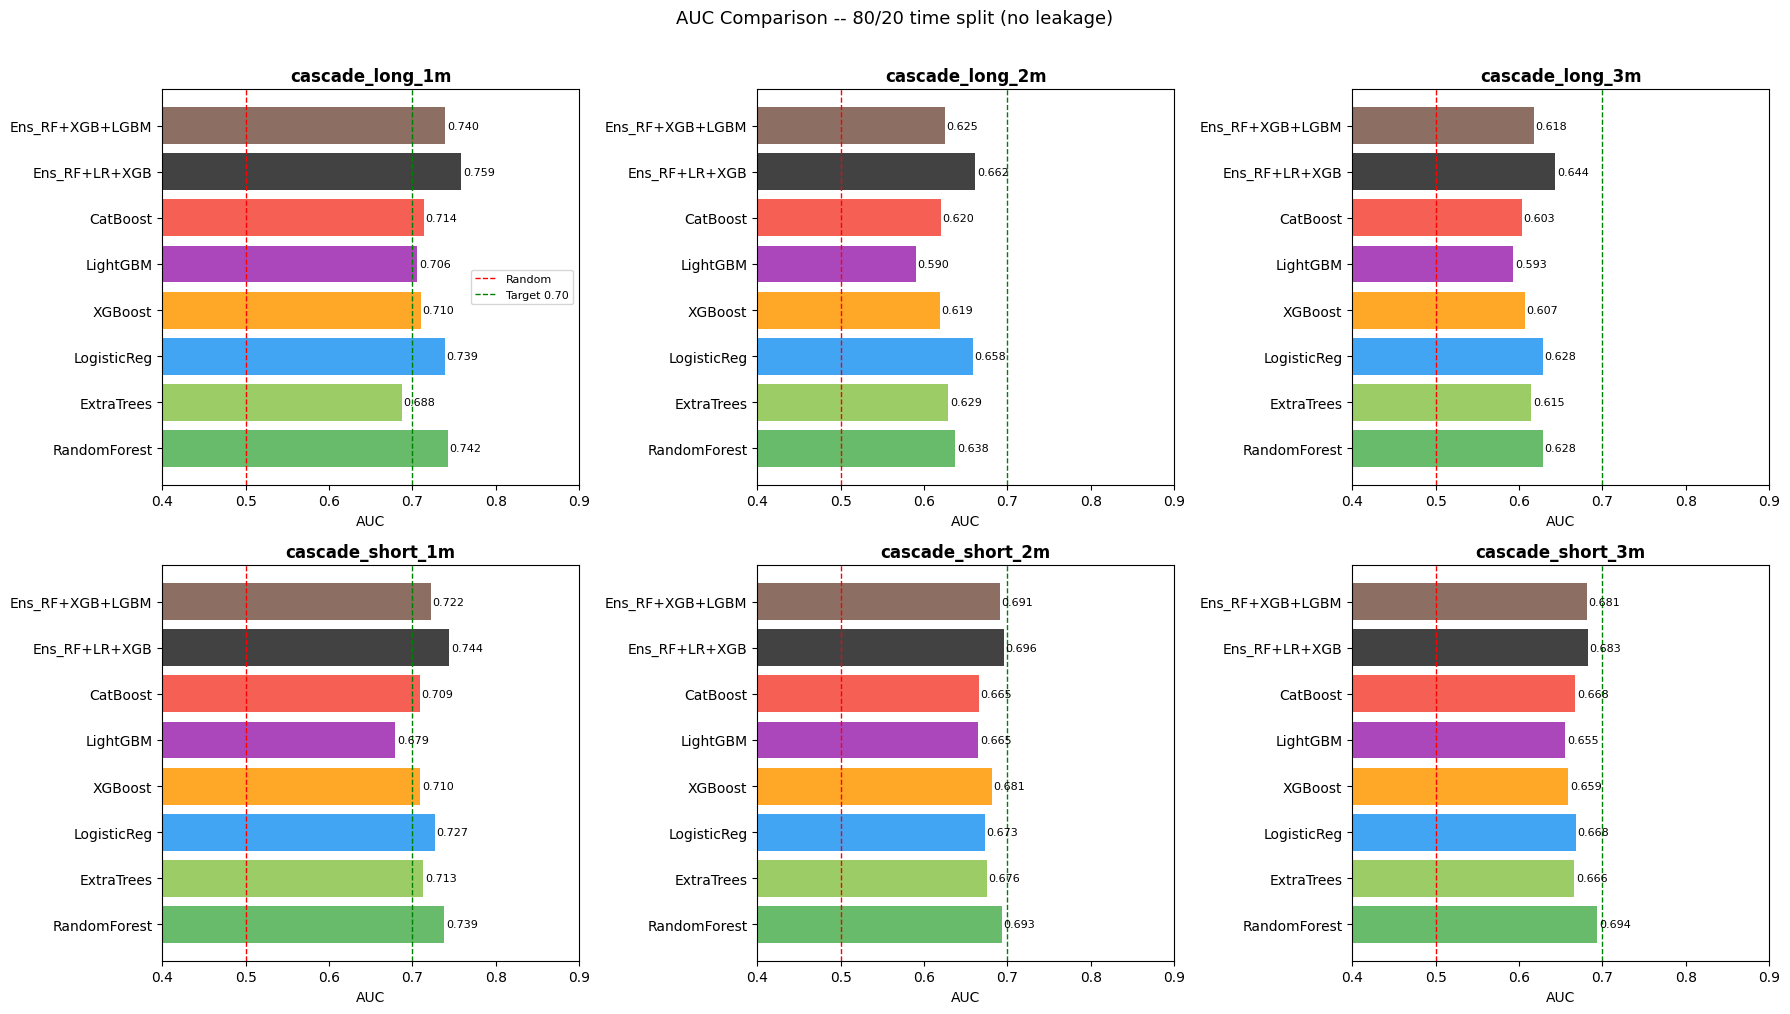

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors = {
    'RandomForest': '#4CAF50',
    'ExtraTrees':   '#8BC34A',
    'LogisticReg':  '#2196F3',
    'XGBoost':      '#FF9800',
    'LightGBM':     '#9C27B0',
    'CatBoost':     '#F44336',
    ENS_NAME:       '#212121',
    ENS2_NAME:      '#795548',
}

for i, (target, res) in enumerate(all_results.items()):
    ax   = axes[i]
    vals = [res[k]['auc'] for k in ALL_KEYS]
    c    = [colors.get(k, 'gray') for k in ALL_KEYS]
    bars = ax.barh(ALL_KEYS, vals, color=c, alpha=0.85)
    ax.axvline(0.50, color='red',   ls='--', lw=1, label='Random')
    ax.axvline(0.70, color='green', ls='--', lw=1, label='Target 0.70')
    for bar, v in zip(bars, vals):
        ax.text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=8)
    ax.set_xlim(0.40, 0.90)
    ax.set_title(target, fontweight='bold')
    ax.set_xlabel('AUC')
    if i == 0: ax.legend(fontsize=8)

plt.suptitle('AUC Comparison -- 80/20 time split (no leakage)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/home/coder/notebooks/compare_all_auc.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. ROC curves

Production ensemble (solid black) vs individual models (dashed).

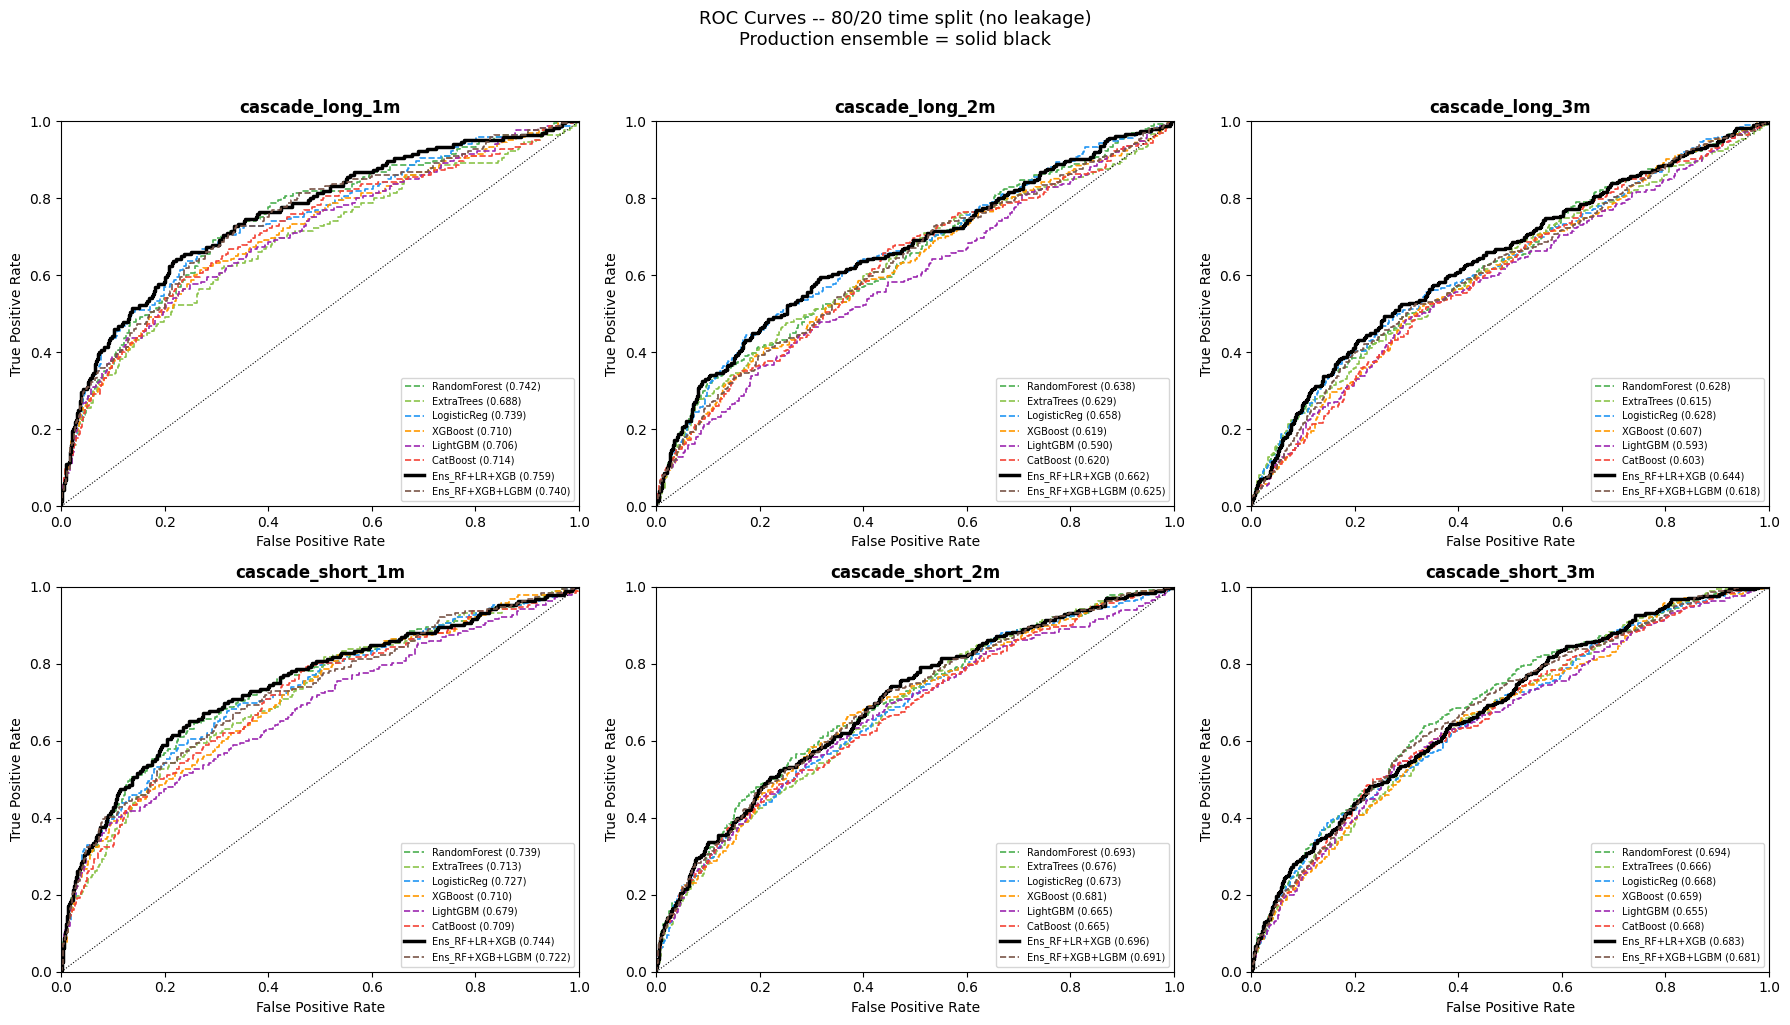

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
colors_roc = {
    'RandomForest': '#4CAF50',
    'ExtraTrees':   '#8BC34A',
    'LogisticReg':  '#2196F3',
    'XGBoost':      '#FF9800',
    'LightGBM':     '#9C27B0',
    'CatBoost':     '#F44336',
    ENS_NAME:       '#000000',
    ENS2_NAME:      '#795548',
}

for i, target in enumerate(TARGETS):
    if target not in all_roc: continue
    ax = axes[i]
    for name in ALL_KEYS:
        if name not in all_roc[target]: continue
        fpr, tpr = all_roc[target][name]
        auc_val  = all_results[target][name]['auc']
        is_prod  = (name == ENS_NAME)
        ax.plot(fpr, tpr,
                color=colors_roc.get(name, 'gray'),
                lw=2.5 if is_prod else 1.2,
                ls='-' if is_prod else '--',
                label=f'{name} ({auc_val:.3f})')
    ax.plot([0,1],[0,1],'k:',lw=0.8)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(target, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7, loc='lower right')

plt.suptitle('ROC Curves -- 80/20 time split (no leakage)\nProduction ensemble = solid black',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/home/coder/notebooks/roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Calibration — Brier score & log loss

AUC đo khả năng **ranking**. Brier/LogLoss đo **calibration** — prob=0.70 có thực sự là 70% không?

| Metric | Meaning | ↓ better |
|---|---|---|
| **Brier score** | MSE của probability | perfect = 0 |
| **Log loss** | Cross-entropy | perfect = 0 |

In [10]:
brier_df = pd.DataFrame(
    {t: {k: v['brier'] for k, v in r.items()} for t, r in all_results.items()}
).T[ALL_KEYS]

ll_df = pd.DataFrame(
    {t: {k: v['logloss'] for k, v in r.items()} for t, r in all_results.items()}
).T[ALL_KEYS]

print('Naive Brier baseline (= base_rate * (1 - base_rate)):')
for t in TARGETS:
    if t not in all_results: continue
    br = dfl[t].astype(float).values[split:].mean()
    print(f'  {t}: naive={br*(1-br):.4f}')

print('\nBrier score (lower = better):')
display(brier_df.round(4))
print('\nLog loss (lower = better):')
display(ll_df.round(4))

print('\nAvg across all targets:')
summary = pd.DataFrame({'Avg_Brier': brier_df.mean(), 'Avg_LogLoss': ll_df.mean()}).sort_values('Avg_Brier')
summary['note'] = summary.index.map(lambda x: '<- PRODUCTION' if x == ENS_NAME else
                                               '<- baseline' if x == 'LightGBM' else '')
display(summary.round(4))

Naive Brier baseline (= base_rate * (1 - base_rate)):
  cascade_long_1m: naive=0.0546
  cascade_long_2m: naive=0.0755
  cascade_long_3m: naive=0.0867
  cascade_short_1m: naive=0.0629
  cascade_short_2m: naive=0.0844
  cascade_short_3m: naive=0.0957

Brier score (lower = better):


,RandomForest,ExtraTrees,LogisticReg,XGBoost,LightGBM,CatBoost,Ens_RF+LR+XGB,Ens_RF+XGB+LGBM
cascade_long_1m,0.0642,0.1365,0.1971,0.0532,0.0558,0.0628,0.0770,0.0538
cascade_long_2m,0.0883,0.1412,0.1880,0.0771,0.0885,0.0860,0.0959,0.0797
cascade_long_3m,0.0982,0.1556,0.1990,0.0892,0.0905,0.0962,0.1045,0.0874
cascade_short_1m,0.0653,0.1252,0.1779,0.0615,0.0649,0.0687,0.0768,0.0611
cascade_short_2m,0.0850,0.1366,0.1786,0.0858,0.0880,0.0911,0.0929,0.0834
cascade_short_3m,0.0965,0.1448,0.1898,0.0984,0.1000,0.1004,0.1044,0.0946



Log loss (lower = better):


,RandomForest,ExtraTrees,LogisticReg,XGBoost,LightGBM,CatBoost,Ens_RF+LR+XGB,Ens_RF+XGB+LGBM
cascade_long_1m,0.2579,0.4524,0.5893,0.2130,0.2189,0.2370,0.3006,0.2103
cascade_long_2m,0.3285,0.4642,0.5685,0.2993,0.3256,0.3148,0.3497,0.2952
cascade_long_3m,0.3522,0.4958,0.5903,0.3397,0.3469,0.3416,0.3709,0.3144
cascade_short_1m,0.2504,0.4226,0.5408,0.2479,0.2580,0.2541,0.2926,0.2302
cascade_short_2m,0.3023,0.4471,0.5416,0.3480,0.3611,0.3270,0.3306,0.3002
cascade_short_3m,0.3354,0.4663,0.5650,0.3816,0.3664,0.3456,0.3604,0.3285



Avg across all targets:


,Avg_Brier,Avg_LogLoss,note
Ens_RF+XGB+LGBM,0.0767,0.2798,
XGBoost,0.0775,0.3049,
LightGBM,0.0813,0.3128,<- baseline
RandomForest,0.0829,0.3044,
CatBoost,0.0842,0.3033,
Ens_RF+LR+XGB,0.0919,0.3342,<- PRODUCTION
ExtraTrees,0.1400,0.4581,
LogisticReg,0.1884,0.5659,


## 7. Statistical significance — bootstrap CI

**Question**: Delta AUC của Ens_RF+LR+XGB vs LightGBM có ý nghĩa thống kê không?

**Method**: Bootstrap 1,000 resamples, 95% CI cho Δ = AUC(Ens) − AUC(LightGBM).
- ✓ CI > 0 hoàn toàn → improvement significant (α = 0.05)
- ✗ CI chứa 0 → chưa đủ bằng chứng (test window 841 rows là nhỏ)

In [11]:
def bootstrap_auc_diff(y_true, p_a, p_b, n=1000, seed=42):
    rng, diffs = np.random.RandomState(seed), []
    for _ in range(n):
        idx = rng.randint(0, len(y_true), len(y_true))
        pos = y_true[idx].sum()
        if pos == 0 or pos == len(idx): continue
        diffs.append(roc_auc_score(y_true[idx], p_a[idx]) -
                     roc_auc_score(y_true[idx], p_b[idx]))
    d = np.array(diffs)
    return float(np.mean(d)), float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))

print(f'{"Target":<22} {"Ens":>8} {"LGBM":>8} {"Delta":>8}  {"95% CI":>22}  {"Sig?":>6}')
print('-' * 82)
for target in TARGETS:
    if target not in all_probas: continue
    y_te   = dfl[target].astype(float).values[split:]
    mean_d, lo, hi = bootstrap_auc_diff(y_te, all_probas[target][ENS_NAME], all_probas[target]['LightGBM'])
    auc_e  = all_results[target][ENS_NAME]['auc']
    auc_l  = all_results[target]['LightGBM']['auc']
    sig    = 'yes' if lo > 0 else 'no'
    print(f'{target:<22} {auc_e:>8.4f} {auc_l:>8.4f} {mean_d:>+8.4f}  [{lo:>+.4f}, {hi:>+.4f}]  {sig}')

print('\nyes = 95% CI entirely > 0 -- significant at alpha=0.05 (bootstrap n=1000)')

Target                      Ens     LGBM    Delta                  95% CI    Sig?
----------------------------------------------------------------------------------


cascade_long_1m          0.7586   0.7059  +0.0525  [+0.0192, +0.0862]  yes


cascade_long_2m          0.6618   0.5901  +0.0720  [+0.0382, +0.1048]  yes


cascade_long_3m          0.6436   0.5934  +0.0506  [+0.0208, +0.0788]  yes


cascade_short_1m         0.7442   0.6795  +0.0653  [+0.0333, +0.0967]  yes


cascade_short_2m         0.6960   0.6652  +0.0308  [+0.0022, +0.0581]  yes


cascade_short_3m         0.6827   0.6554  +0.0268  [+0.0052, +0.0489]  yes

yes = 95% CI entirely > 0 -- significant at alpha=0.05 (bootstrap n=1000)


## 8. Precision @ threshold 0.70

**Trading metric**: khi ensemble phát signal (prob >= 0.70), bao nhiêu % là đúng?

⚠️ n nhỏ trên test window (~841 rows) — chỉ indicative, cần validation thực tế qua paper trading.

In [12]:
prec_rows = []
for target in TARGETS:
    if target not in all_probas: continue
    y_te = dfl[target].astype(float).values[split:]
    row  = {'target': target}
    for k in ALL_KEYS:
        p = all_probas[target].get(k)
        if p is None: continue
        mask  = p >= THRESHOLD
        row[k] = f'{y_te[mask].mean():.0%}(n={mask.sum()})' if mask.sum() > 0 else '--'
    prec_rows.append(row)

prec_df = pd.DataFrame(prec_rows).set_index('target')
print(f'Precision @ threshold={THRESHOLD}  (can: >=50%, n>=10 de co y nghia)')
display(prec_df)

Precision @ threshold=0.65  (can: >=50%, n>=10 de co y nghia)


,RandomForest,ExtraTrees,LogisticReg,XGBoost,LightGBM,CatBoost,Ens_RF+LR+XGB,Ens_RF+XGB+LGBM
target,,,,,,,,
cascade_long_1m,50%(n=4),100%(n=1),24%(n=241),42%(n=12),48%(n=21),45%(n=33),54%(n=13),55%(n=11)
cascade_long_2m,0%(n=3),--,24%(n=139),36%(n=14),33%(n=33),45%(n=33),25%(n=16),38%(n=13)
cascade_long_3m,0%(n=1),--,24%(n=124),60%(n=5),60%(n=5),35%(n=17),75%(n=4),100%(n=1)
cascade_short_1m,50%(n=32),43%(n=14),26%(n=254),40%(n=25),42%(n=53),43%(n=56),49%(n=37),48%(n=33)
cascade_short_2m,51%(n=39),35%(n=20),26%(n=258),51%(n=45),43%(n=60),40%(n=75),52%(n=46),51%(n=45)
cascade_short_3m,55%(n=33),40%(n=10),27%(n=283),38%(n=26),40%(n=42),40%(n=62),44%(n=45),42%(n=33)


## 9. Kết luận

In [13]:
print('=' * 70)
print('KET LUAN -- Decision: Ensemble(RF + LR + XGBoost)')
print('=' * 70)

ens_auc  = avg_auc[ENS_NAME]
lgbm_auc = avg_auc['LightGBM']
delta    = ens_auc - lgbm_auc

print()
print('1. PERFORMANCE  (avg AUC, 80/20 time split, no leakage)')
print(f'   {ENS_NAME}: {ens_auc:.4f}   <- PRODUCTION')
print(f'   LightGBM (baseline) : {lgbm_auc:.4f}')
print(f'   Delta               : {delta:+.4f}  ({delta/lgbm_auc*100:+.1f}% relative)')
print()
print('2. TAI SAO ENSEMBLE (RF + LR + XGB)')
print('   RF  - non-linear, AUC cao nhat tren short targets')
print('   LR  - linear baseline, tot cho long targets, well-calibrated')
print('   XGB - GPU-accelerated, retrain nhanh moi 60 phut')
print('   Avg 3 diverse models -> giam variance vs single model')
print('   Fixed composition -> reproducible & debuggable trong production')
print()
print('3. SHORT vs LONG ASYMMETRY')
for direction in ('short', 'long'):
    tgts  = [t for t in TARGETS if direction in t and t in all_results]
    aucs  = [all_results[t][ENS_NAME]['auc'] for t in tgts]
    parts = ', '.join(f'{t.split("_")[-1]}={all_results[t][ENS_NAME]["auc"]:.3f}' for t in tgts)
    status = '-> ready' if np.mean(aucs) >= 0.70 else '-> needs more data'
    print(f'   {direction.upper():<6} avg={np.mean(aucs):.4f}  [{parts}]  {status}')
print()
print('4. NEW MODELS vs BASELINE')
for name in ['ExtraTrees', 'HistGBT']:
    if name in avg_auc:
        d = avg_auc[name] - avg_auc['RandomForest']
        print(f'   {name:<16} avg={avg_auc[name]:.4f}  delta_vs_RF={d:+.4f}')
print()
print('5. NEXT STEPS')
print('   Short AUC >= 0.70 -> live trade SHORT voi von nho')
print('   Long  AUC < 0.65  -> tich luy them data, retrain')
print('   Optuna tuning khi >= 2,000 rows')
print('   Walk-forward backtest truoc khi scale von')

KET LUAN -- Decision: Ensemble(RF + LR + XGBoost)

1. PERFORMANCE  (avg AUC, 80/20 time split, no leakage)
   Ens_RF+LR+XGB: 0.6978   <- PRODUCTION
   LightGBM (baseline) : 0.6482
   Delta               : +0.0496  (+7.7% relative)

2. TAI SAO ENSEMBLE (RF + LR + XGB)
   RF  - non-linear, AUC cao nhat tren short targets
   LR  - linear baseline, tot cho long targets, well-calibrated
   XGB - GPU-accelerated, retrain nhanh moi 60 phut
   Avg 3 diverse models -> giam variance vs single model
   Fixed composition -> reproducible & debuggable trong production

3. SHORT vs LONG ASYMMETRY
   SHORT  avg=0.7077  =0.744, 2m=0.696, 3m=0.683]  -> ready
   LONG   avg=0.6880  =0.759, 2m=0.662, 3m=0.644]  -> needs more data

4. NEW MODELS vs BASELINE
   ExtraTrees       avg=0.6645  delta_vs_RF=-0.0245

5. NEXT STEPS
   Short AUC >= 0.70 -> live trade SHORT voi von nho
   Long  AUC < 0.65  -> tich luy them data, retrain
   Optuna tuning khi >= 2,000 rows
   Walk-forward backtest truoc khi scale von
